In [1]:
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from typing import Optional, Union, List
import warnings
warnings.filterwarnings('ignore')

print(f"✓ PyTorch {torch.__version__} loaded")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

✓ PyTorch 2.9.1 loaded
✓ CUDA available: False


In [2]:
# ============================================================================
# INFERENCE CONFIGURATION
# ============================================================================

# Paths (uses same portable BASE_DIR as training notebook)
BASE_DIR = Path(os.getenv("PIXELCLEAR_ROOT", Path.cwd()))
CHECKPOINT_DIR = BASE_DIR / "experiments" / "baseline_training"
OUTPUT_DIR = BASE_DIR / "inference_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Model configuration (must match training config)
MODEL_CONFIG = {
    "base_channels": 32,
    "num_blocks": 4,
    "dropout": 0.0,
}

# Checkpoint path
CHECKPOINT_PATH = CHECKPOINT_DIR / "best_model.pth"  # or "last_model.pth"

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\n{'='*60}")
print("Inference Configuration")
print(f"{'='*60}")
print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"{'='*60}\n")


Inference Configuration
Device: cpu
Checkpoint: /Users/sachithwickramaseakara/Desktop/FYP/Implementation/PixelClear/experiments/baseline_training/best_model.pth
Output directory: /Users/sachithwickramaseakara/Desktop/FYP/Implementation/PixelClear/inference_results



In [3]:
# ============================================================================
# MODEL ARCHITECTURE (Same as training)
# ============================================================================

class SimpleGate(nn.Module):
    """Simple gating mechanism for activation."""
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class NAFBlock(nn.Module):
    """NAFNet block: Simple and effective restoration block."""
    def __init__(self, channels: int, dropout: float = 0.0):
        super().__init__()
        self.dwconv = nn.Conv2d(channels, channels, kernel_size=3, padding=1, groups=channels)
        self.norm = nn.LayerNorm(channels)
        self.pwconv1 = nn.Conv2d(channels, channels * 2, kernel_size=1)
        self.act = SimpleGate()
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.pwconv2 = nn.Conv2d(channels, channels, kernel_size=1)
        
    def forward(self, x):
        residual = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = x.permute(0, 3, 1, 2)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.pwconv2(x)
        return x + residual

class BaselineRestorationModel(nn.Module):
    """Lightweight baseline restoration model."""
    def __init__(self, base_channels: int = 32, num_blocks: int = 4, dropout: float = 0.0):
        super().__init__()
        self.input_conv = nn.Conv2d(3, base_channels, kernel_size=3, padding=1)
        self.blocks = nn.Sequential(*[
            NAFBlock(base_channels, dropout=dropout)
            for _ in range(num_blocks)
        ])
        self.output_conv = nn.Conv2d(base_channels, 3, kernel_size=3, padding=1)
        
    def forward(self, x):
        residual = x
        x = self.input_conv(x)
        x = self.blocks(x)
        x = self.output_conv(x)
        return x + residual

print("✓ Model architecture defined")

✓ Model architecture defined


In [4]:

# LOAD TRAINED MODEL

# Create model
model = BaselineRestorationModel(
    base_channels=MODEL_CONFIG["base_channels"],
    num_blocks=MODEL_CONFIG["num_blocks"],
    dropout=MODEL_CONFIG["dropout"]
).to(DEVICE)

# Load checkpoint
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}\nRun training first!")

print(f"Loading checkpoint: {CHECKPOINT_PATH}")
# Note: weights_only=False is safe since this is our own checkpoint from training
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Model loaded successfully!")
print(f"  Epoch: {checkpoint.get('epoch', 'unknown')}")
print(f"  Best PSNR: {checkpoint.get('best_val_psnr', checkpoint.get('val_psnr', 'unknown')):.2f} dB")

Loading checkpoint: /Users/sachithwickramaseakara/Desktop/FYP/Implementation/PixelClear/experiments/baseline_training/best_model.pth
✓ Model loaded successfully!
  Epoch: 5
  Best PSNR: 27.87 dB


In [5]:
# INFERENCE FUNCTIONS

def load_image(image_path: Union[str, Path]) -> Image.Image:
    """Load and convert image to RGB."""
    img = Image.open(image_path)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    return img

def preprocess_image(img: Image.Image, max_size: Optional[int] = None) -> torch.Tensor:
    """Preprocess image for model input."""
    # Resize if too large (optional)
    if max_size:
        w, h = img.size
        if max(w, h) > max_size:
            scale = max_size / max(w, h)
            new_w, new_h = int(w * scale), int(h * scale)
            img = img.resize((new_w, new_h), Image.BILINEAR)
    
    # Convert to tensor and normalize to [0, 1]
    tensor = TF.to_tensor(img)
    return tensor.unsqueeze(0)  # Add batch dimension

def postprocess_image(tensor: torch.Tensor) -> Image.Image:
    """Convert model output tensor back to PIL Image."""
    # Remove batch dimension and clamp to [0, 1]
    tensor = tensor.squeeze(0).clamp(0, 1)
    return TF.to_pil_image(tensor)

def restore_image(
    model: nn.Module,
    image_path: Union[str, Path],
    device: torch.device,
    max_size: Optional[int] = None
) -> Image.Image:
    """
    Restore a single image using the trained model.
    
    Args:
        model: Trained restoration model
        image_path: Path to input image
        device: Device to run inference on
        max_size: Optional max dimension (for large images)
    
    Returns:
        Restored PIL Image
    """
    # Load and preprocess
    img = load_image(image_path)
    input_tensor = preprocess_image(img, max_size=max_size).to(device)
    
    # Run inference
    with torch.no_grad():
        output_tensor = model(input_tensor)
    
    # Postprocess
    restored_img = postprocess_image(output_tensor)
    
    return restored_img

print("✓ Inference functions defined")

✓ Inference functions defined


In [6]:
# VISUALIZATION FUNCTION

def visualize_restoration(
    input_img: Image.Image,
    restored_img: Image.Image,
    save_path: Optional[Path] = None,
    title: str = "Image Restoration"
):
    """Visualize input and restored images side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(input_img)
    axes[0].set_title("Input (Degraded)", fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(restored_img)
    axes[1].set_title("Restored", fontsize=14)
    axes[1].axis('off')
    
    plt.suptitle(title, fontsize=16, y=0.98)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved visualization: {save_path}")
    
    plt.show()

print("✓ Visualization function defined")

✓ Visualization function defined


Processing: /Users/sachithwickramaseakara/Downloads/000001.png
✓ Saved visualization: /Users/sachithwickramaseakara/Desktop/FYP/Implementation/PixelClear/inference_results/restoration_comparison.png


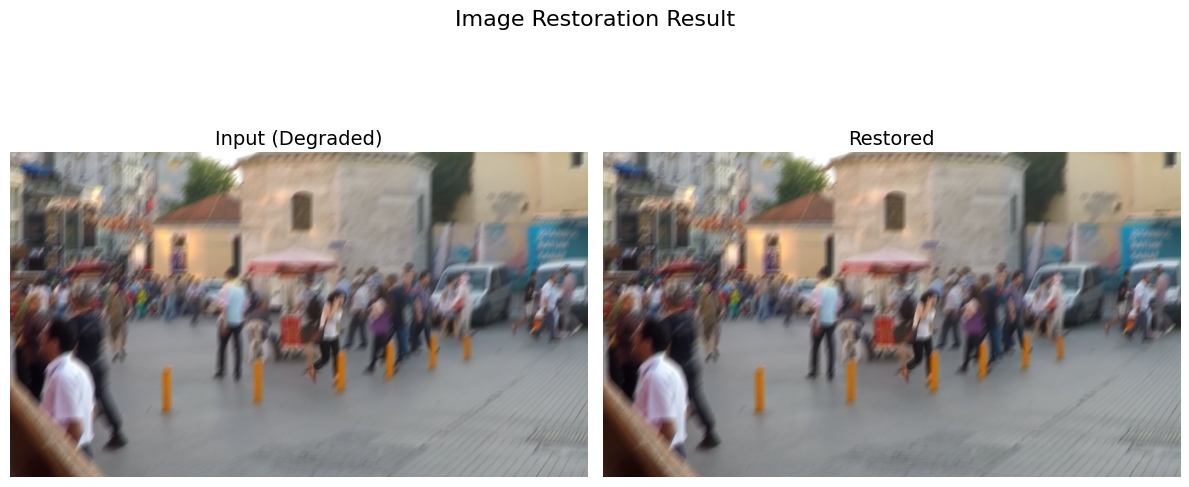

✓ Saved restored image: /Users/sachithwickramaseakara/Desktop/FYP/Implementation/PixelClear/inference_results/restored_000001.png


In [10]:
# EXAMPLE: RESTORE SINGLE IMAGE
# Set your image path here
INPUT_IMAGE_PATH = "/Users/sachithwickramaseakara/Downloads/000001.png"

# Restore image
if Path(INPUT_IMAGE_PATH).exists():
    print(f"Processing: {INPUT_IMAGE_PATH}")
    restored = restore_image(model, INPUT_IMAGE_PATH, DEVICE, max_size=1024)
    
    # Visualize
    input_img = load_image(INPUT_IMAGE_PATH)
    visualize_restoration(
        input_img,
        restored,
        save_path=OUTPUT_DIR / "restoration_comparison.png",
        title="Image Restoration Result"
    )
    
    # Save restored image
    output_path = OUTPUT_DIR / f"restored_{Path(INPUT_IMAGE_PATH).name}"
    restored.save(output_path)
    print(f"✓ Saved restored image: {output_path}")
else:
    print(f"⚠️  Image not found: {INPUT_IMAGE_PATH}")
    print("   Please update INPUT_IMAGE_PATH with a valid image path")

In [9]:
def process_batch(
    model: nn.Module,
    image_paths: List[Union[str, Path]],
    device: torch.device,
    output_dir: Path,
    max_size: Optional[int] = None
):
    """Process multiple images in batch."""
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\nProcessing {len(image_paths)} images...")
    for i, img_path in enumerate(image_paths, 1):
        img_path = Path(img_path)
        if not img_path.exists():
            print(f"⚠️  Skipping {img_path.name}: not found")
            continue
        
        print(f"[{i}/{len(image_paths)}] Processing {img_path.name}...")
        
        try:
            # Restore
            restored = restore_image(model, img_path, device, max_size=max_size)
            
            # Save
            output_path = output_dir / f"restored_{img_path.name}"
            restored.save(output_path)
            print(f"  ✓ Saved: {output_path}")
            
        except Exception as e:
            print(f"  ✗ Error: {e}")
    
    print(f"\n✓ Batch processing complete!")
    print(f"  Results saved to: {output_dir}")

# Example usage (uncomment and modify):
# image_list = [
#     "path/to/image1.jpg",
#     "path/to/image2.jpg",
#     "path/to/image3.jpg",
# ]
# process_batch(model, image_list, DEVICE, OUTPUT_DIR / "batch_results")